In [1]:
%load_ext autoreload
%autoreload 2
import xarray as xr 
import os
import yaml
import matplotlib.pyplot as plt 
import matplotlib as mpl
from glacierwide_loss import * 

In [2]:
output_fp = '/ocean/projects/ees260009p/cwilson4/Output/gridsearch_gulkana_0/'
ds_all = xr.open_zarr(output_fp + 'output.zarr')
ds_all['time'] = ds_all.time - pd.Timedelta(hours=8)

with open(output_fp + 'config.yaml') as f:
    configs = yaml.safe_load(f) 

sites = np.unique(configs['sites'])
rgiids = np.unique(configs['rgi_ids'])

assert ds_all.error.sum().values <= 1e-3

In [3]:
wfs = np.array(configs['wind_factor'])
kps = np.array(configs['kp'])
kds = np.array(configs['dust_factor'])

ab = Albedo('gulkana')
sm = SnowlineMelt('gulkana')

# only keep the necessary variables in memory
needed_vars = ['albedo', 'surftype', 'surftemp', 'melt', 'lon', 'lat']
ds_loss = ds_all[needed_vars].load()

ab.get_model_albedo(ds_loss)
sm.get_model_snow(ds_loss)

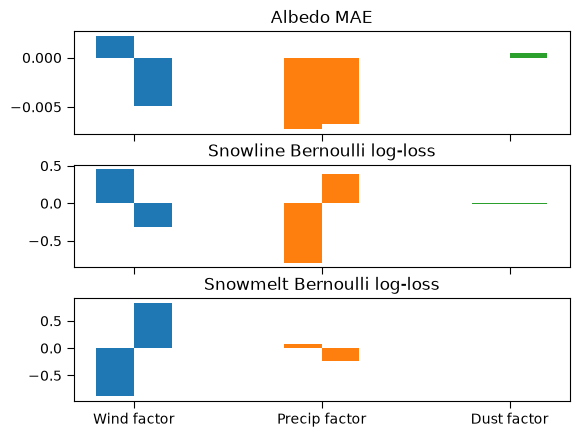

In [11]:
results = np.empty((3, 3, 3, 3))
for w, wf in enumerate(np.unique(wfs)):
    for p, kp in enumerate(np.unique(kps)):
        for d, kd in enumerate(np.unique(kds)):
            points = np.where((wfs == wf) & (kps == kp) & (kds == kd))[0]

            mae = ab.mae(ab.mod[:, points], ab.meas[:, points])
            snow_loss, melt_loss = sm.bernoulli_loss(
                sm.mod_snow[:, points], sm.meas_snow[:, points],
                sm.mod_melt[:, points], sm.meas_melt[:, points])

            results[w, p, d, :] = [mae, snow_loss, melt_loss]
            # print(results[w, p, d, :])

fig, axes = plt.subplots(3, gridspec_kw={'hspace': 0.3, 'wspace': 0.3}, sharex=True)
labels = ['Wind factor','Precip factor','Dust factor']

for i, label in enumerate(['Albedo MAE', 'Snowline Bernoulli log-loss', 'Snowmelt Bernoulli log-loss']):
    ax = axes[i]

    for j, (idx) in enumerate([(slice(None), 1, 1, i), (1, slice(None), 1, i), (1, 1, slice(None), i)]):
        pt_result = results[idx][1] - results[idx][[0, 2]]
        
        ax.bar([j-0.1, j+0.1], pt_result, width=0.2)

    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_title(label)
    ax.tick_params(length=5)
plt.show()